# Ejercicio 3

Utilice las herramientas aprendidas en esta unidad para implementar un sistema que permita identificar una botella que no est´correctamente llena. Las imágenes que se proporcionarán son capturadas con una cámara fija, en escala de grises y directamente de la línea de envasado. Para implementar el sistema deberá bastarle una imagen de ejemplo "botella.tif" (que encontrará en el repositorio). Adicionalmentem se espera que el sistema pueda:

- Identificar una botella *no-llena* en cualquier posición de la imagen
- Indicar la posición de la botella en la imagen (podría ser con un recuadro, informando la posición relativa entre botellas, la posición absoluta en píxeles, etc).
- Informar el porcentaje de llenado de la botella *no-llena*.

### Cargar librerias e imagen

In [92]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# imagen
img = cv2.imread("botellas.tif")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

### Identificar posicion

In [93]:
# imagen con valores binarios segun un umbral
img_silueta = np.where(np.greater(img_gray, 10), 1, 0)

# Detectar posicion horizontal de las botellas
# Se realiza un "scanline" a la altura de y=100
botellas_x = []

init = -1
i = 0
while i < img_silueta.shape[1]:
    # detectar cuando "empieza" una botella
    if img_silueta[100,i] == 1:
        init = i

        # buscar cuando "termina" una botella (o la imagen)
        j = i
        while j < img_silueta.shape[1] and img_silueta[100, j] == 1:
            j += 1
        botellas_x.append([init, j])
        i = j
    i += 1

# Detectar posicion vertical
botellas_y = [[] for _ in range(len(botellas_x))]
# se aplica un umbral a la imagen para exagerar los "limites"
img_threshold = np.where(np.greater(img_gray, 200), 1, 0)
for i, botella in enumerate(botellas_x):
    # promedio horizontal
    prom_x = np.mean(img_threshold[:, botella[0]:botella[1]], axis=1)
    j = 0
    while j < prom_x.shape[0]:
        # detectamos la parte superior de la botella
        if prom_x[j] > 0.4:
            tapa = j
            # buscamos el nivel del liquido
            k = j
            while k < prom_x.shape[0] and prom_x[k] > 0.4:
                k += 1
            # guardamos los niveles de la botella
            botellas_y[i] = [tapa, k]
            break
        j += 1


### Medir llenado

In [94]:
llenado = [0 for _ in range(len(botellas_x))]
for i, botella in enumerate(botellas_y):
    llenado[i] = 1 - (botella[1] - botella[0])/(img.shape[0] - botella[0])
print(llenado)

[0.8162162162162162, 0.8315217391304348, 0.6486486486486487, 0.8315217391304348, 0.8216216216216217]


### Resultado

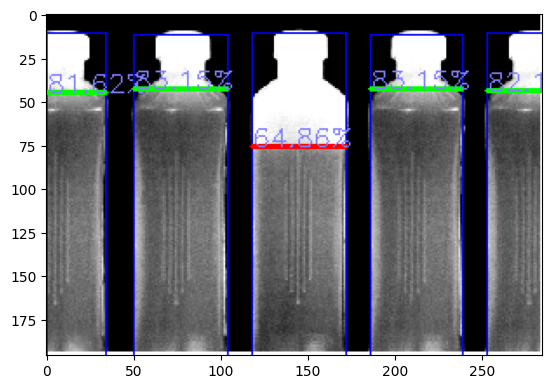

In [95]:
for i in range(len(botellas_x)):
    # dibujar contorno de las botellas
    cv2.rectangle(img, (botellas_x[i][0], botellas_y[i][0]), (botellas_x[i][1], img.shape[0]), (0, 0, 255), 1)
    # dibujar nivel del liquido
    cv2.line(img, (
        botellas_x[i][0],
        botellas_y[i][1]),
        (botellas_x[i][1], botellas_y[i][1]),
        (255, 0, 0) if llenado[i] < 0.8 else (0, 255, 0),
        2
    )
    # porcentaje de llenado
    cv2.putText(
        img,
        "{:.2f}%".format(llenado[i]*100),
        (botellas_x[i][0], botellas_y[i][1]),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (128, 128, 255),
        1
    )

# visualizacion test
fig, ax = plt.subplots(1, 1)

ax.imshow(img, cmap="gray");